In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt


In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
words = open('/kaggle/input/datasets/ayushuttarwar/makemore-names/names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [4]:
len(words)

32033

In [5]:
# building vocabulary and mapping to ints
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0

itos = {i:s for s, i in stoi.items()}
vocab_size = len(itos)
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [6]:
# dataset building
block_size=3

def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0]*block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

In [7]:
# data splitting
import random
random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

X_tr, Y_tr = build_dataset(words[:n1]) # 80%
X_val, Y_val = build_dataset(words[n1:n2])  # 10%
X_test, Y_test = build_dataset(words[n2:]) # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [8]:
# MLP neural net
n_embed = 10 # dimensionality of char embedding vector
n_hidden = 200 # #neurons in hidden layer

g = torch.Generator().manual_seed(1337)
C = torch.randn((vocab_size, n_embed), generator=g)
W1 = torch.randn((n_embed * block_size, n_hidden), generator=g) 
b1 = torch.randn(n_hidden, generator=g) 
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) # total params
for p in parameters:
    p.requires_grad = True

11897


In [9]:
# training loop
max_steps = 100000
batch_size = 32
lossi=[]

for i in range(max_steps):
    # minibatch
    ix = torch.randint(0, X_tr.shape[0], (batch_size,), generator=g)
    Xb, Yb = X_tr[ix], Y_tr[ix]

    # forward pass
    emb = C[Xb] # convert to vectors
    embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
    hpreact = embcat @ W1 + b1 # hidden layer
    h = torch.tanh(hpreact) # activation
    logits = h @ W2 + b2 # output layer
    loss = F.cross_entropy(logits, Yb) # loss

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update weights
    lr = 0.1 if i < 50000 else 0.01 # step down
    for p in parameters:
        p.data += -lr*p.grad

    # track stats
    if i % 10000 == 0: 
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    # break

      0/ 100000: 3.3383
  10000/ 100000: 2.2458
  20000/ 100000: 2.1912
  30000/ 100000: 2.3310
  40000/ 100000: 2.4027
  50000/ 100000: 2.2919
  60000/ 100000: 1.9360
  70000/ 100000: 1.8486
  80000/ 100000: 1.9761
  90000/ 100000: 1.8543


## Problem-01

One of the major problem of our model is it's initialization technique. If we see the change in loss after first 10K iterations, it dropped significantly. In DL while building a neural net, weights init technique plays an important role. It enables model to learn correct pattern.

Another thing is while predicting the first char of word the probability of each chars must be equal. Because at initilisation there is not reason to believe that there is a probability of any char is more than any one. 

Therefore, we expect the initial probability distribution is equal for every character.

So,  
*prob. if any char = 1/27*  
*loss = -log(1/27)   &nbsp; -- negative log probability*  
Therefore, **loss = 3.29** which is lot lower than our initial loss. This signifies that the probability distribution of characters is not unified

In [10]:
# understand the same using an example
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log() # taking label as 2
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [11]:
# now the loss is same but the probs have large differences
logits = torch.tensor([0.0, 0.0, 3.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log() # taking label as 2
probs, loss

(tensor([0.0433, 0.0433, 0.8700, 0.0433]), tensor(0.1392))

## Problem-02

h-values. 

After going through the activation function most of the values are getting equals to **-1** or **1**.  
There are very less no. of values which lies between them.  

Below is the plot showcasing the same

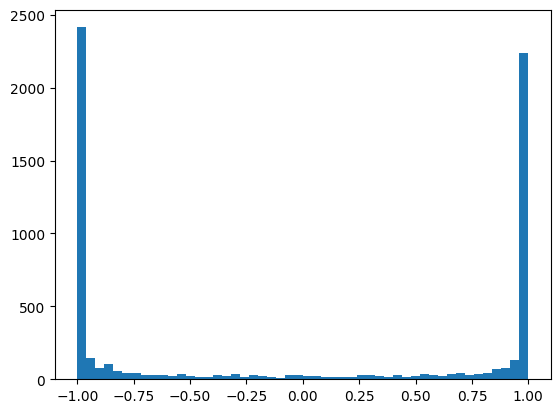

In [12]:
plt.hist(h.view(-1).tolist(), 50);

Also,  
the distribution of pre-activation is broderly distributed.

Below is the plot showcasing the same

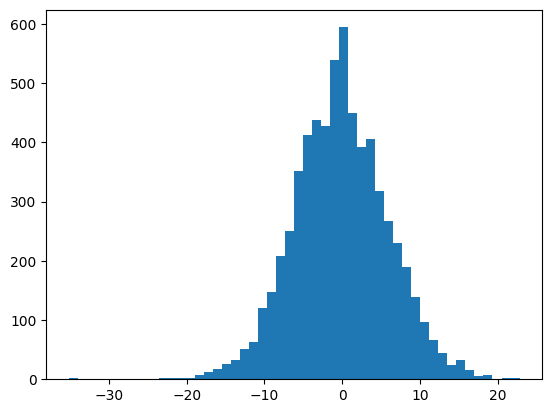

In [13]:
plt.hist(hpreact.view(-1).tolist(), 50);

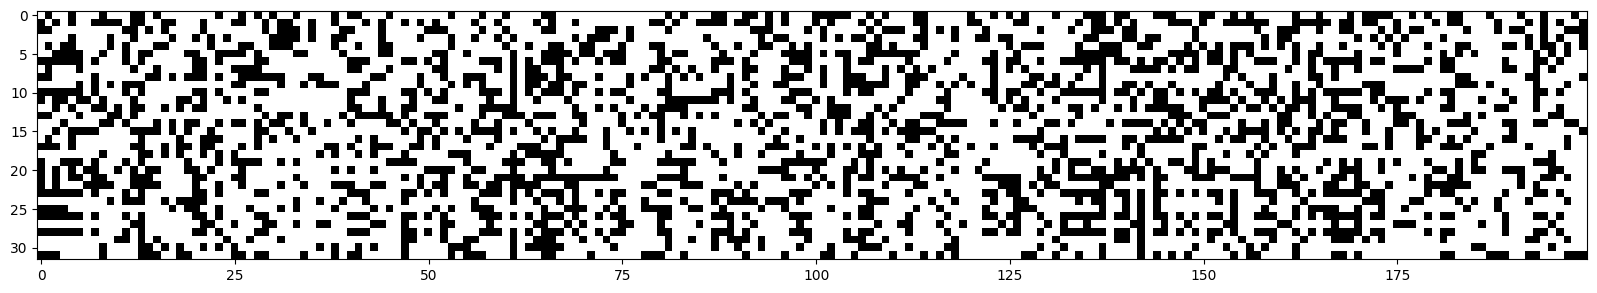

In [14]:
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap='gray', interpolation='nearest')

white area shows --> h.abs() > 0.99, that means backward gradient of that neuron is destroyed.

if there is a column where all the dots are **white coloured** then that means it's a **dead neuron**. Which indidcates that none of the input activated that neuron and it hasn't learnt anything. Glad that we don't have them.

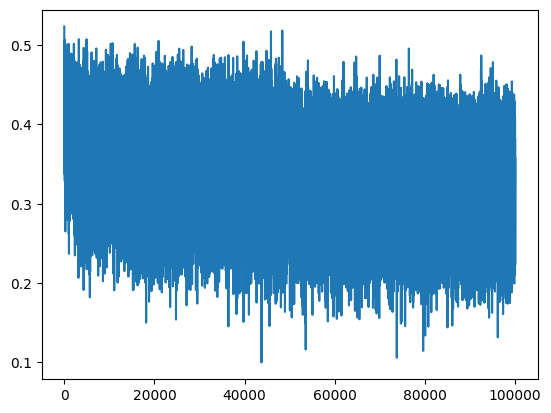

In [15]:
plt.plot(lossi)

after changing the values of W2 and b2, the plot has changed (previously it was kind of a hockey shape graph). Now the difference in loss is quite comparable.

In [16]:
@torch.no_grad() # disables gradient tracking
def split_loss(split):
    x, y = {
        'train': (X_tr, Y_tr),
        'val': (X_val, Y_val),
        'test': (X_test, Y_test),
    }[split]
    emb = C[x] # (N, block_size, n_embed)
    embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embed)
    h = torch.tanh(embcat @ W1 + b1) # (N, n_hidden)
    logits = h @ W2 + b2 # (N, vocab_size)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0986382961273193
val 2.1514062881469727


Here also the loss is decreased by 0.2

In [17]:
# sampling from model
g = torch.Generator().manual_seed(1337)

for _ in range(20):
    out = []
    context = [0] * block_size 
    while True:
        # forward pass
        emb = C[torch.tensor([context])] # [1, block_size, n_embed]
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)

        # sample from distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()

        # shift the context window and track samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we get the special '.' tokrn, break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

gun.
kateliy.
dmaeduleighelaleahmanissa.
zalani.
zanyn.
vyana.
taesynn.
graya.
esvayion.
dar.
alaydena.
kei.
srai.
laier.
ander.
halylar.
sa.
jani.
aaran.
jesta.


These generated words are better than our previous model. We are improving our model. But it still not accurate, it needs lots of improvements. Next we will try to build a RNN model to predict the next character